# Analisis Data Eksploratif (EDA) - Perbandingan Kekeringan & Cuaca Kansas vs Nebraska

Notebook ini dibuat khusus untuk melakukan Exploratory Data Analysis (EDA) secara mendalam untuk membandingkan kondisi cuaca dan status kekeringan antara dua wilayah utama: **Kansas (KS)** dan **Nebraska (NE)** menggunakan data mingguan tingkat county (subset 20 county).

### Sumber Data:
1. **NASA POWER Daily Weather Data**: Suhu (`T2M`), Curah Hujan (`PRECTOTCORR`), Kelembapan Relatif (`RH2M`), Tekanan Permukaan (`PS`), Kecepatan Angin (`WS2M`), Radiasi Matahari (`ALLSKY_SFC_SW_DWN`).
2. **U.S. Drought Monitor (USDM) Weekly**: Persentase kumulatif area county yang berada di kategori kekeringan None (normal), D0, D1, D2, D3, dan D4.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Dataset paths (20 counties subset)
KAN_PATH = 'Integrated_weekly_KAN_20counties.csv'
NEB_PATH = 'Integrated_weekly_NEB_20counties.csv'

print("Libraries imported and paths configured.")

Libraries imported and paths configured.


## 1. Load Data & Preprocessing

Langkah awal adalah memuat data cuaca harian NASA POWER yang diintegrasikan ke mingguan serta data USDM (U.S. Drought Monitor) mingguan. Kami juga melakukan:
1. **Dekumulasi**: Persentase area kelas kekeringan USDM (None, D0-D4) didekumulasi menjadi nilai probabilitas eksklusif (`PMF_None`, `PMF_D0` s.d `PMF_D4`).
2. **Penentuan Label Dominan**: Memetakan kelas kekeringan dominan (Label 0 s.d 5) untuk setiap baris data.

In [2]:
def decumulate_drought(row):
    pmf_d4 = row['D4']
    pmf_d3 = max(0.0, row['D3'] - row['D4'])
    pmf_d2 = max(0.0, row['D2'] - row['D3'])
    pmf_d1 = max(0.0, row['D1'] - row['D2'])
    pmf_d0 = max(0.0, row['D0'] - row['D1'])
    pmf_none = max(0.0, row['None'])
    return pd.Series([pmf_none, pmf_d0, pmf_d1, pmf_d2, pmf_d3, pmf_d4])

pmf_cols = ['PMF_None', 'PMF_D0', 'PMF_D1', 'PMF_D2', 'PMF_D3', 'PMF_D4']
label_map = {0: 'None', 1: 'D0', 2: 'D1', 3: 'D2', 4: 'D3', 5: 'D4'}

def load_and_preprocess(filepath, state_name):
    print(f"Loading {state_name} dataset from {filepath}...")
    df = pd.read_csv(filepath)
    df['week_start'] = pd.to_datetime(df['week_start'])
    df['ValidEnd'] = pd.to_datetime(df['ValidEnd'])
    df = df.sort_values(['FIPS', 'week_start']).reset_index(drop=True)
    
    # Lakukan dekumulasi
    df[pmf_cols] = df.apply(decumulate_drought, axis=1)
    # Beri label kelas dominan (indeks dengan PMF terbesar)
    df['Label'] = df[pmf_cols].idxmax(axis=1).apply(lambda x: pmf_cols.index(x))
    df['Drought_Class'] = df['Label'].map(label_map)
    
    print(f"-> Selesai memuat {len(df):,} baris data untuk {df['FIPS'].nunique()} county unik.\n")
    return df

df_kan = load_and_preprocess(KAN_PATH, "Kansas")
df_neb = load_and_preprocess(NEB_PATH, "Nebraska")

Loading Kansas dataset from Integrated_weekly_KAN_20counties.csv...
-> Selesai memuat 16,720 baris data untuk 20 county unik.

Loading Nebraska dataset from Integrated_weekly_NEB_20counties.csv...
-> Selesai memuat 16,720 baris data untuk 20 county unik.



## 2. Statistik Deskriptif & Perbandingan Dataset

Berikut adalah ringkasan dimensi data, rentang waktu, county unik, serta nilai kosong antara dataset Kansas (KS) dan Nebraska (NE).

In [3]:
summary_data = {
    "Parameter": [
        "Jumlah Baris (Rows)",
        "Jumlah Kolom (Columns)",
        "Jumlah County Unik (FIPS)",
        "Rentang Waktu Awal (Min Date)",
        "Rentang Waktu Akhir (Max Date)",
        "Total Nilai Kosong (Missing Values)"
    ],
    "Kansas (KS)": [
        df_kan.shape[0],
        df_kan.shape[1],
        df_kan['FIPS'].nunique(),
        df_kan['week_start'].min().strftime('%Y-%m-%d'),
        df_kan['week_start'].max().strftime('%Y-%m-%d'),
        df_kan.isnull().sum().sum()
    ],
    "Nebraska (NE)": [
        df_neb.shape[0],
        df_neb.shape[1],
        df_neb['FIPS'].nunique(),
        df_neb['week_start'].min().strftime('%Y-%m-%d'),
        df_neb['week_start'].max().strftime('%Y-%m-%d'),
        df_neb.isnull().sum().sum()
    ]
}
df_summary = pd.DataFrame(summary_data)
df_summary

,Parameter,Kansas (KS),Nebraska (NE)
0,Jumlah Baris (Rows),16720,16720
1,Jumlah Kolom (Columns),28,28
2,Jumlah County Unik (FIPS),20,20
3,Rentang Waktu Awal (Min Date),2009-12-29,2009-12-29
4,Rentang Waktu Akhir (Max Date),2025-12-30,2025-12-30
5,Total Nilai Kosong (Missing Values),0,0


## 3. Distribusi Kelas Kekeringan (Drought Class Distribution)

Mari kita bandingkan persentase frekuensi dominansi dari setiap tingkatan kekeringan (Label 0 s.d 5) di kedua wilayah. Hal ini penting untuk mengukur tingkat ketidakseimbangan kelas (class imbalance) sebelum pemodelan klasifikasi.

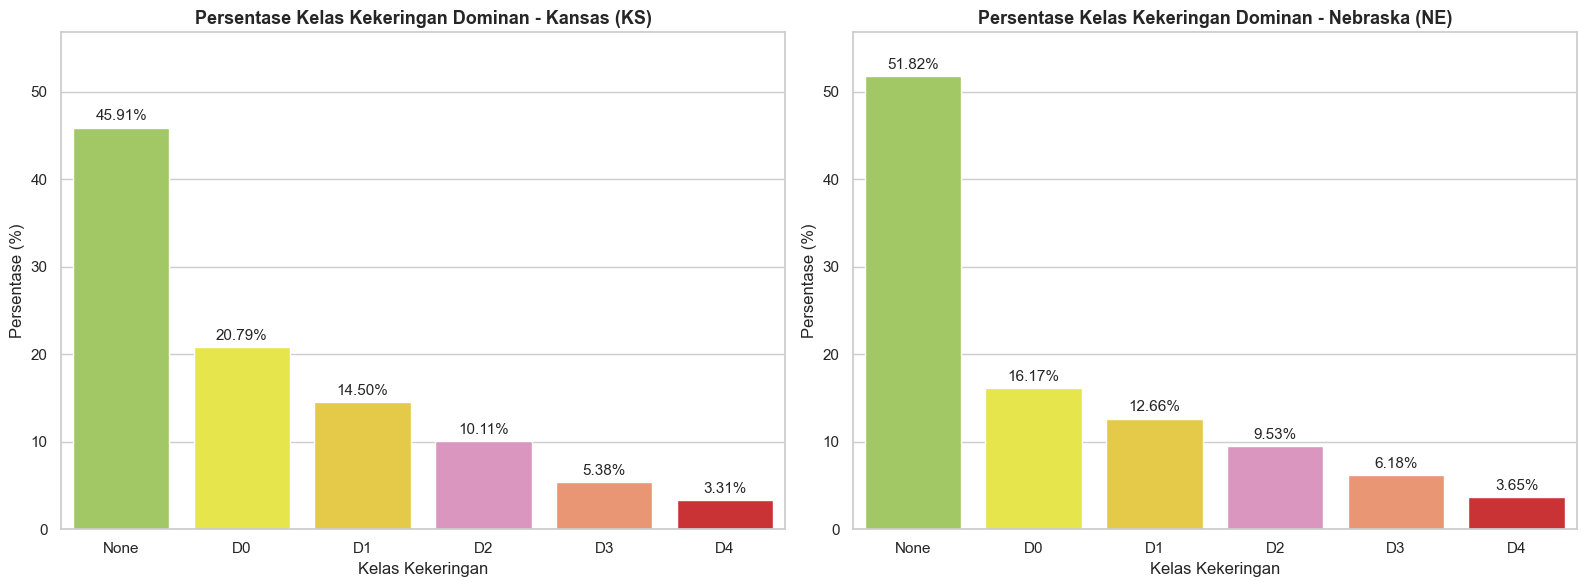

In [4]:
# Hitung proporsi kelas
dist_kan = df_kan['Drought_Class'].value_counts(normalize=True).reindex(['None', 'D0', 'D1', 'D2', 'D3', 'D4']).fillna(0) * 100
dist_neb = df_neb['Drought_Class'].value_counts(normalize=True).reindex(['None', 'D0', 'D1', 'D2', 'D3', 'D4']).fillna(0) * 100

df_dist = pd.DataFrame({
    'Kansas (%)': dist_kan,
    'Nebraska (%)': dist_neb
}).reset_index().rename(columns={'index': 'Drought_Class'})

# Palette warna standar USDM
usdm_colors = ['#a6d854', '#ffff33', '#ffd92f', '#e78ac3', '#fc8d62', '#e31a1c']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kansas
sns.barplot(data=df_dist, x='Drought_Class', y='Kansas (%)', palette=usdm_colors, ax=axes[0], hue='Drought_Class', legend=False)
axes[0].set_title("Persentase Kelas Kekeringan Dominan - Kansas (KS)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Persentase (%)")
axes[0].set_xlabel("Kelas Kekeringan")
axes[0].set_ylim(0, max(df_dist['Kansas (%)'].max(), df_dist['Nebraska (%)'].max()) + 5)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Nebraska
sns.barplot(data=df_dist, x='Drought_Class', y='Nebraska (%)', palette=usdm_colors, ax=axes[1], hue='Drought_Class', legend=False)
axes[1].set_title("Persentase Kelas Kekeringan Dominan - Nebraska (NE)", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Persentase (%)")
axes[1].set_xlabel("Kelas Kekeringan")
axes[1].set_ylim(0, max(df_dist['Kansas (%)'].max(), df_dist['Nebraska (%)'].max()) + 5)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 4. Perkembangan Kekeringan Historis (Drought Progression Timeline)

Grafik *stacked area* ini menunjukkan proporsi luas wilayah yang berada di bawah level kekeringan yang berbeda dari waktu ke waktu secara mingguan sejak 2010 hingga 2025. Kita bisa melihat pola siklus kekeringan besar (misal kekeringan dahsyat tahun 2012-2013) di kedua wilayah.

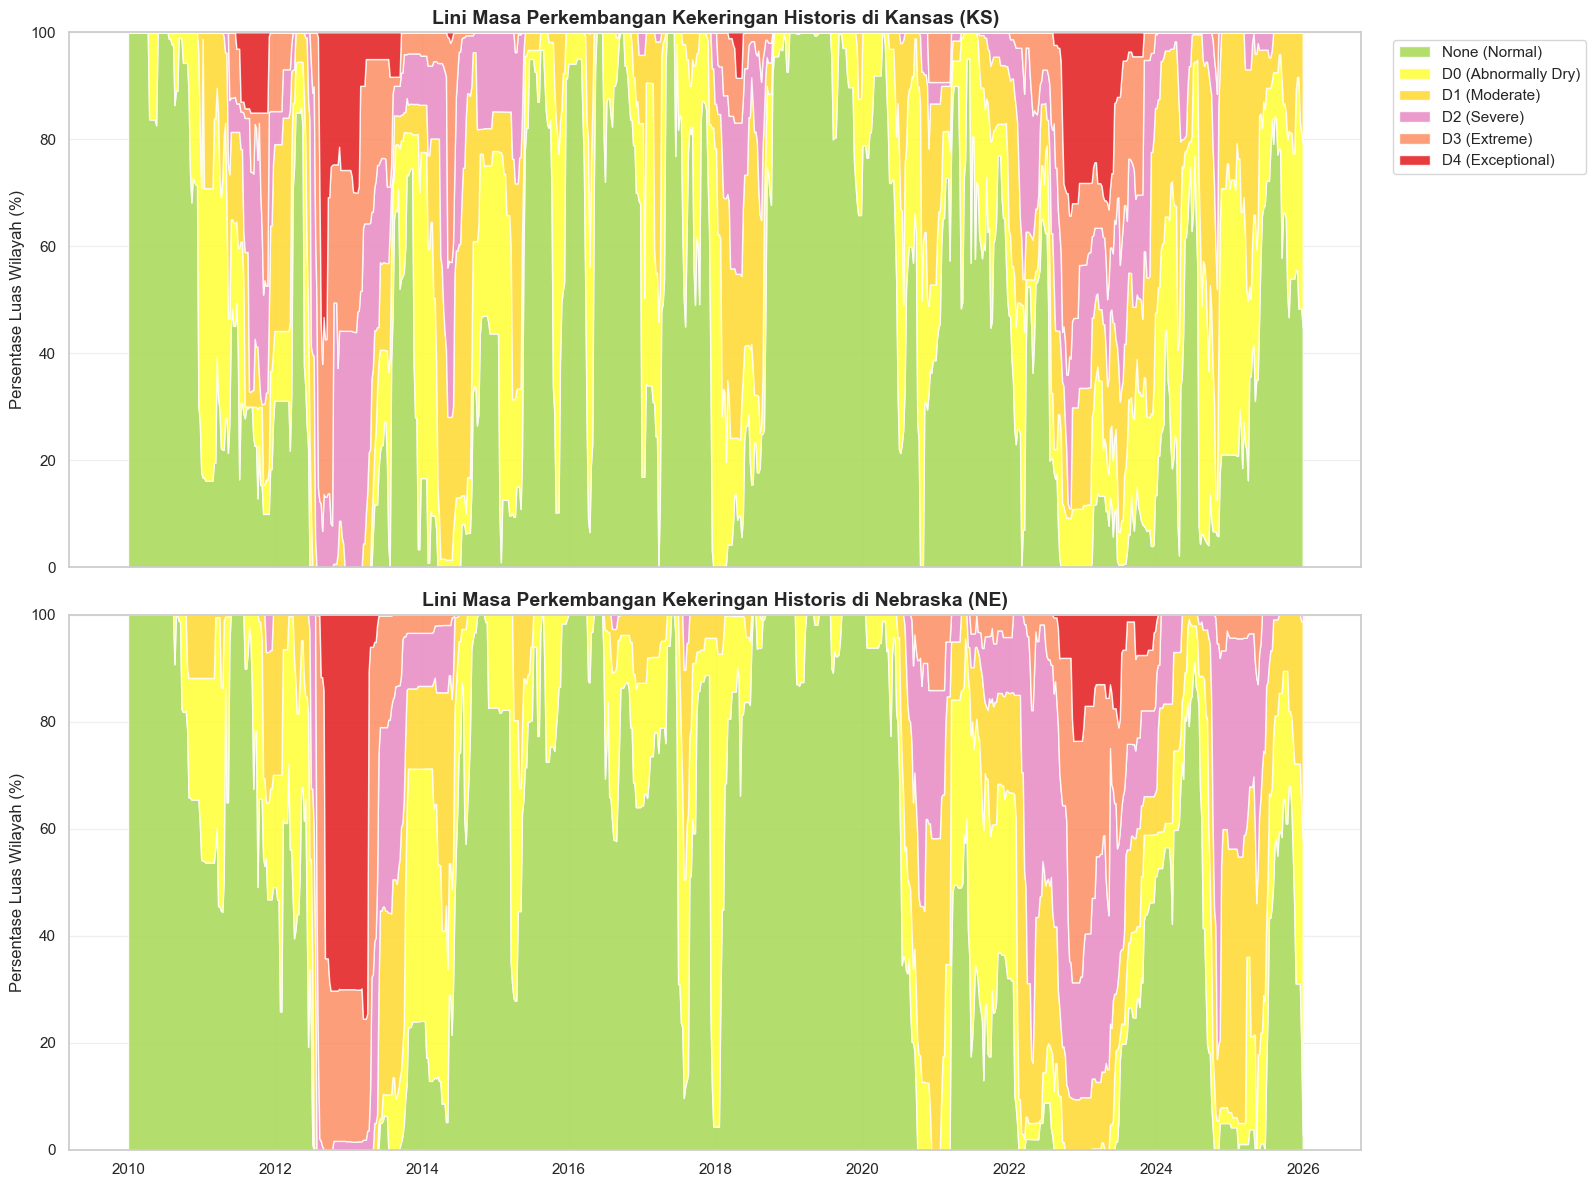

In [5]:
def plot_drought_progression(df, title, ax):
    # Kelompokkan mingguan lalu cari rata-rata persentase luasan
    weekly_avg = df.groupby('week_start')[['None', 'D0', 'D1', 'D2', 'D3', 'D4']].mean()
    
    # Dekumulasi data rata-rata agar dapat di-plot bertumpuk
    pmf_avg = pd.DataFrame(index=weekly_avg.index)
    pmf_avg['D4'] = weekly_avg['D4']
    pmf_avg['D3'] = (weekly_avg['D3'] - weekly_avg['D4']).clip(lower=0)
    pmf_avg['D2'] = (weekly_avg['D2'] - weekly_avg['D3']).clip(lower=0)
    pmf_avg['D1'] = (weekly_avg['D1'] - weekly_avg['D2']).clip(lower=0)
    pmf_avg['D0'] = (weekly_avg['D0'] - weekly_avg['D1']).clip(lower=0)
    pmf_avg['None'] = weekly_avg['None']
    
    # Normalisasi agar pas 100%
    total = pmf_avg.sum(axis=1)
    for col in pmf_avg.columns:
        pmf_avg[col] = (pmf_avg[col] / total) * 100
        
    ax.stackplot(pmf_avg.index, 
                 pmf_avg['None'], pmf_avg['D0'], pmf_avg['D1'], pmf_avg['D2'], pmf_avg['D3'], pmf_avg['D4'],
                 labels=['None (Normal)', 'D0 (Abnormally Dry)', 'D1 (Moderate)', 'D2 (Severe)', 'D3 (Extreme)', 'D4 (Exceptional)'],
                 colors=['#a6d854', '#ffff33', '#ffd92f', '#e78ac3', '#fc8d62', '#e31a1c'],
                 alpha=0.85)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Persentase Luas Wilayah (%)")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
plot_drought_progression(df_kan, "Lini Masa Perkembangan Kekeringan Historis di Kansas (KS)", axes[0])
plot_drought_progression(df_neb, "Lini Masa Perkembangan Kekeringan Historis di Nebraska (NE)", axes[1])

axes[0].legend(loc='upper right', bbox_to_anchor=(1.18, 1.0))
plt.tight_layout()
plt.show()

## 5. Analisis Klimatologi Bulanan & Pola Musiman Fitur Cuaca

Kita bandingkan rata-rata bulanan (climatology) dari indikator cuaca utama:
- **T2M**: Temperatur Rata-rata 2 Meter (°C)
- **PRECTOTCORR**: Curah Hujan Rata-rata (mm/hari)
- **RH2M**: Kelembapan Relatif pada Ketinggian 2 Meter (%)

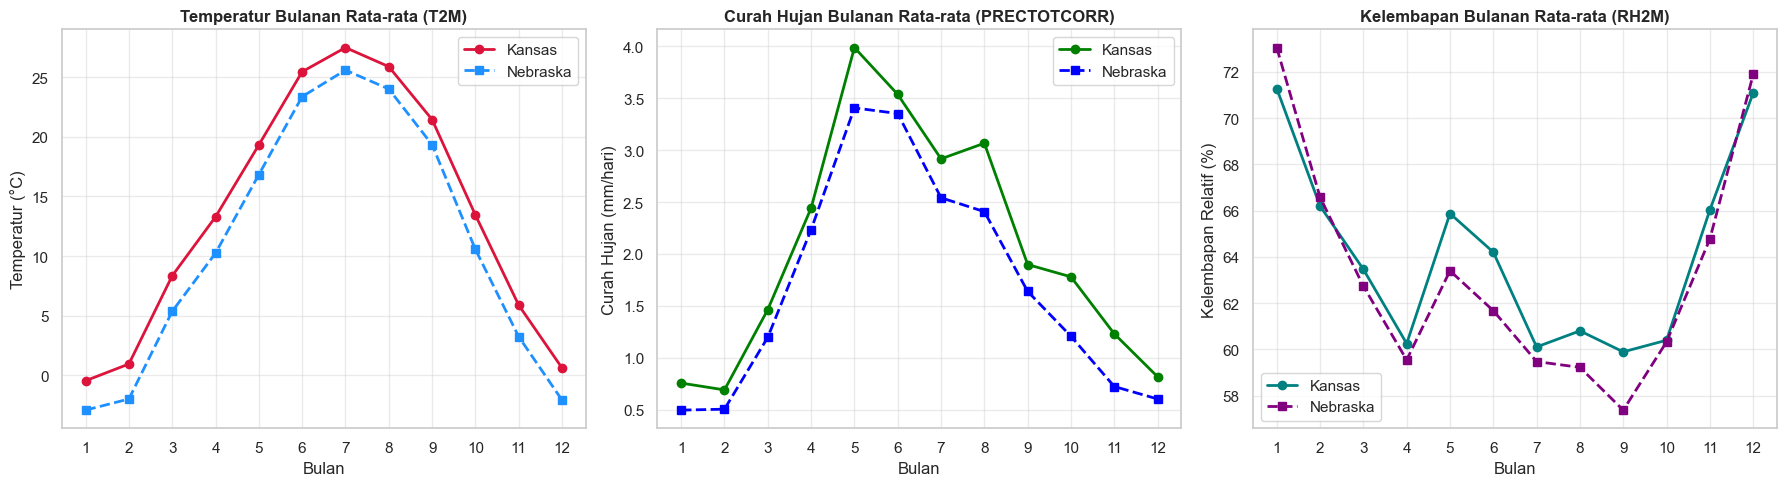

In [6]:
# Ekstrak bulan
df_kan['Month'] = df_kan['week_start'].dt.month
df_neb['Month'] = df_neb['week_start'].dt.month

# Hitung rata-rata bulanan
monthly_kan = df_kan.groupby('Month')[['T2M', 'PRECTOTCORR', 'RH2M']].mean().reset_index()
monthly_neb = df_neb.groupby('Month')[['T2M', 'PRECTOTCORR', 'RH2M']].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Temperatur (T2M)
axes[0].plot(monthly_kan['Month'], monthly_kan['T2M'], marker='o', color='crimson', label='Kansas', linewidth=2)
axes[0].plot(monthly_neb['Month'], monthly_neb['T2M'], marker='s', color='dodgerblue', label='Nebraska', linewidth=2, linestyle='--')
axes[0].set_title("Temperatur Bulanan Rata-rata (T2M)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Temperatur (°C)")
axes[0].set_xlabel("Bulan")
axes[0].set_xticks(range(1, 13))
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Curah Hujan (PRECTOTCORR)
axes[1].plot(monthly_kan['Month'], monthly_kan['PRECTOTCORR'], marker='o', color='green', label='Kansas', linewidth=2)
axes[1].plot(monthly_neb['Month'], monthly_neb['PRECTOTCORR'], marker='s', color='blue', label='Nebraska', linewidth=2, linestyle='--')
axes[1].set_title("Curah Hujan Bulanan Rata-rata (PRECTOTCORR)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Curah Hujan (mm/hari)")
axes[1].set_xlabel("Bulan")
axes[1].set_xticks(range(1, 13))
axes[1].legend()
axes[1].grid(True, alpha=0.4)

# Kelembapan (RH2M)
axes[2].plot(monthly_kan['Month'], monthly_kan['RH2M'], marker='o', color='teal', label='Kansas', linewidth=2)
axes[2].plot(monthly_neb['Month'], monthly_neb['RH2M'], marker='s', color='purple', label='Nebraska', linewidth=2, linestyle='--')
axes[2].set_title("Kelembapan Bulanan Rata-rata (RH2M)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Kelembapan Relatif (%)")
axes[2].set_xlabel("Bulan")
axes[2].set_xticks(range(1, 13))
axes[2].legend()
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## 6. Karakteristik Fitur Cuaca per Kelas Kekeringan

Kita menganalisis sebaran variabel cuaca pada masing-masing tingkatan kekeringan dominan. Hal ini memvalidasi secara fisik hubungan antara variabel meteorologi dan kondisi kekeringan di permukaan tanah.

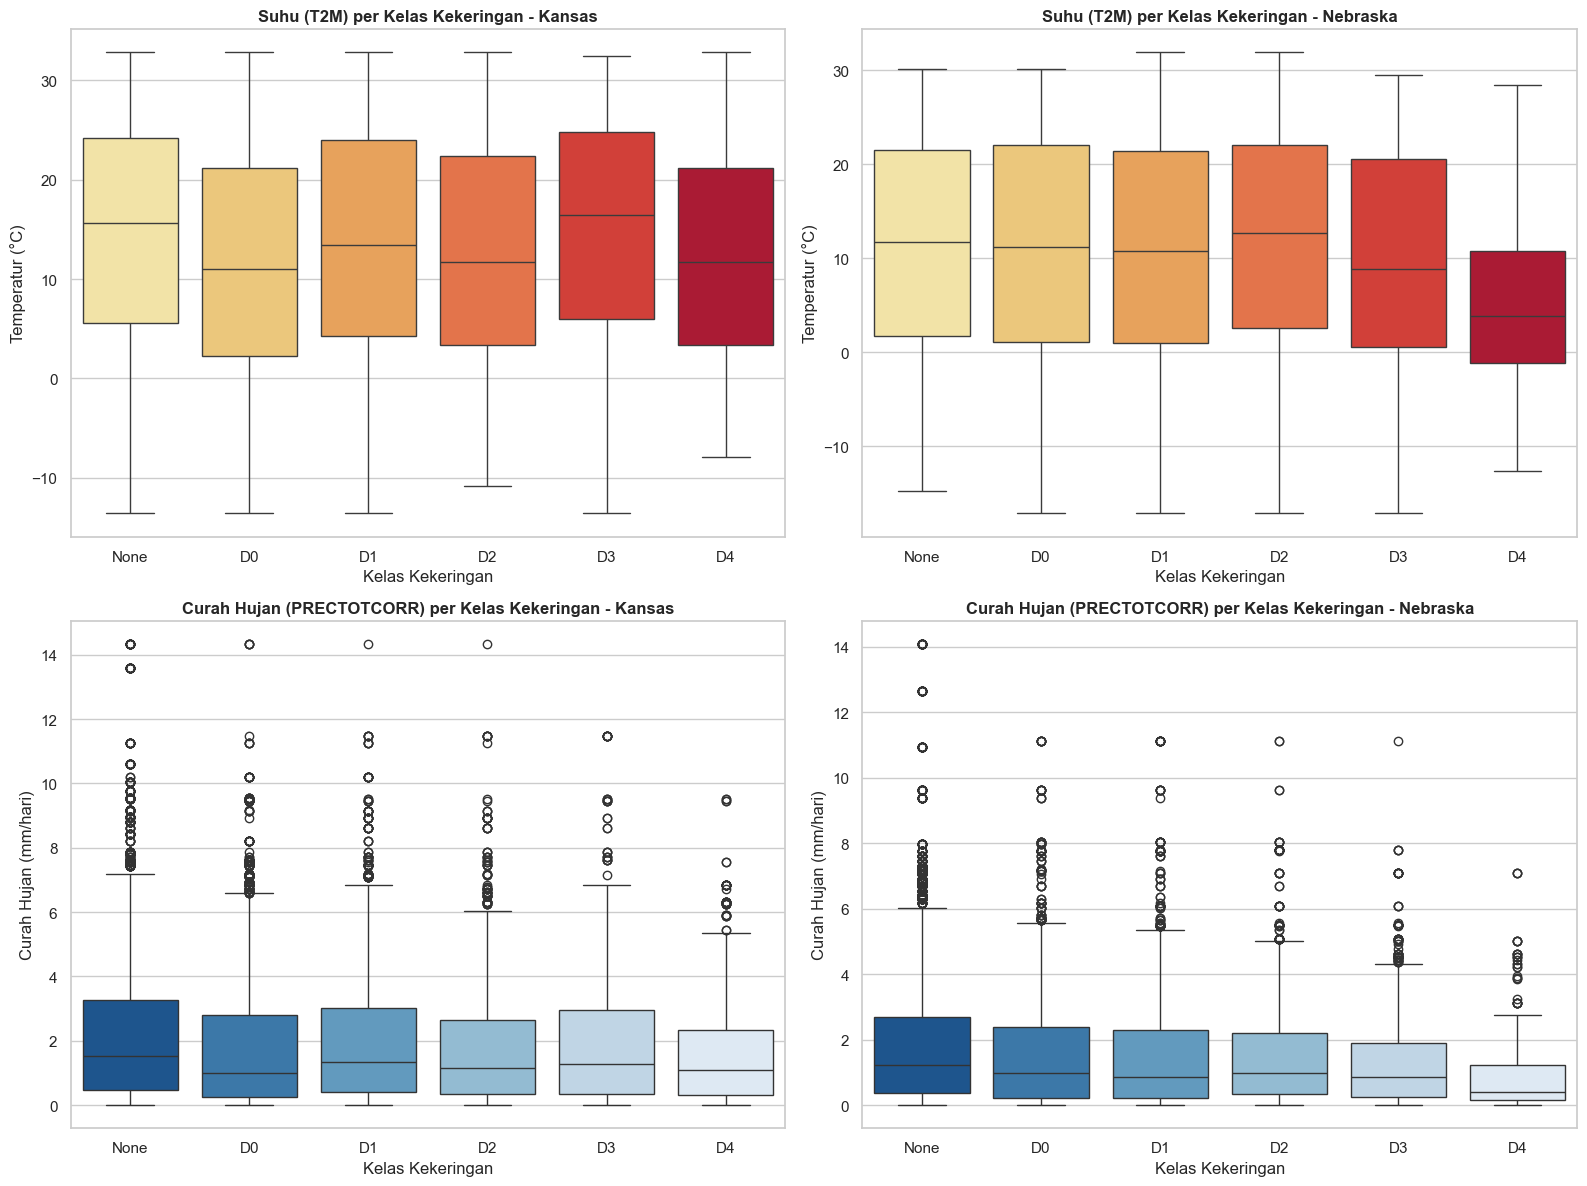

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
order_classes = ['None', 'D0', 'D1', 'D2', 'D3', 'D4']

# Suhu - Kansas
sns.boxplot(data=df_kan, x='Drought_Class', y='T2M', order=order_classes, palette='YlOrRd', ax=axes[0, 0], hue='Drought_Class', legend=False)
axes[0, 0].set_title("Suhu (T2M) per Kelas Kekeringan - Kansas", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Temperatur (°C)")
axes[0, 0].set_xlabel("Kelas Kekeringan")

# Suhu - Nebraska
sns.boxplot(data=df_neb, x='Drought_Class', y='T2M', order=order_classes, palette='YlOrRd', ax=axes[0, 1], hue='Drought_Class', legend=False)
axes[0, 1].set_title("Suhu (T2M) per Kelas Kekeringan - Nebraska", fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel("Temperatur (°C)")
axes[0, 1].set_xlabel("Kelas Kekeringan")

# Curah Hujan - Kansas
sns.boxplot(data=df_kan, x='Drought_Class', y='PRECTOTCORR', order=order_classes, palette='Blues_r', ax=axes[1, 0], hue='Drought_Class', legend=False)
axes[1, 0].set_title("Curah Hujan (PRECTOTCORR) per Kelas Kekeringan - Kansas", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("Curah Hujan (mm/hari)")
axes[1, 0].set_xlabel("Kelas Kekeringan")

# Curah Hujan - Nebraska
sns.boxplot(data=df_neb, x='Drought_Class', y='PRECTOTCORR', order=order_classes, palette='Blues_r', ax=axes[1, 1], hue='Drought_Class', legend=False)
axes[1, 1].set_title("Curah Hujan (PRECTOTCORR) per Kelas Kekeringan - Nebraska", fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel("Curah Hujan (mm/hari)")
axes[1, 1].set_xlabel("Kelas Kekeringan")

plt.tight_layout()
plt.show()

## 7. Analisis Korelasi & Fitur Lag (Efek Tunda Cuaca)

Kekeringan biasanya timbul dari akumulasi deficit curah hujan dan anomali suhu panas selama beberapa minggu/bulan sebelumnya (lagging effect). 
Di bawah ini, kita akan membuat fitur lag (1, 2, 4, 8, dan 12 minggu) untuk curah hujan (`PRECTOTCORR`), suhu (`T2M`), dan kelembapan (`RH2M`), lalu memetakan korelasi Pearson-nya terhadap label kekeringan (`Label`).

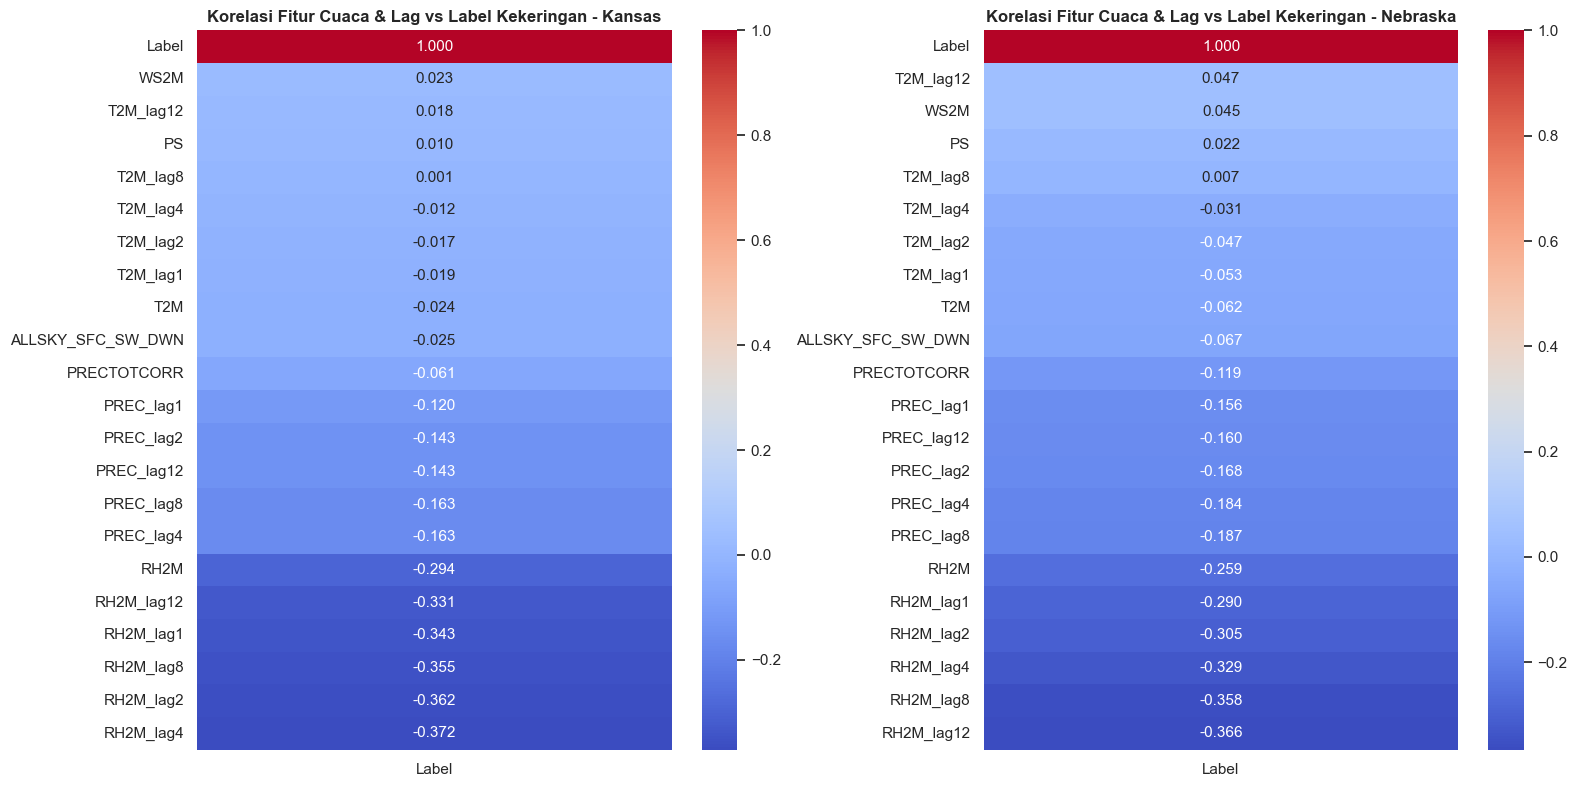

In [8]:
def calculate_lags_and_corrs(df_in):
    df = df_in.copy().sort_values(['FIPS', 'week_start']).reset_index(drop=True)
    
    # Hitung lag 1, 2, 4, 8, dan 12 minggu untuk fitur cuaca utama
    for lag in [1, 2, 4, 8, 12]:
        df[f'PREC_lag{lag}'] = df.groupby('FIPS')['PRECTOTCORR'].shift(lag)
        df[f'T2M_lag{lag}'] = df.groupby('FIPS')['T2M'].shift(lag)
        df[f'RH2M_lag{lag}'] = df.groupby('FIPS')['RH2M'].shift(lag)
        
    # Definisikan kolom fitur untuk korelasi dengan target Label
    corr_cols = [
        'Label', 'PRECTOTCORR', 'T2M', 'RH2M', 'ALLSKY_SFC_SW_DWN', 'WS2M', 'PS',
        'PREC_lag1', 'PREC_lag2', 'PREC_lag4', 'PREC_lag8', 'PREC_lag12',
        'T2M_lag1', 'T2M_lag2', 'T2M_lag4', 'T2M_lag8', 'T2M_lag12',
        'RH2M_lag1', 'RH2M_lag2', 'RH2M_lag4', 'RH2M_lag8', 'RH2M_lag12'
    ]
    
    return df[corr_cols].corr()

corr_kan = calculate_lags_and_corrs(df_kan)
corr_neb = calculate_lags_and_corrs(df_neb)

# Visualisasi Heatmap korelasi terhadap Label
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(corr_kan[['Label']].sort_values(by='Label', ascending=False), annot=True, cmap='coolwarm', fmt=".3f", ax=axes[0])
axes[0].set_title("Korelasi Fitur Cuaca & Lag vs Label Kekeringan - Kansas", fontsize=12, fontweight='bold')

sns.heatmap(corr_neb[['Label']].sort_values(by='Label', ascending=False), annot=True, cmap='coolwarm', fmt=".3f", ax=axes[1])
axes[1].set_title("Korelasi Fitur Cuaca & Lag vs Label Kekeringan - Nebraska", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Ringkasan Temuan & Implikasi untuk Pemodelan

Berdasarkan hasil analisis data eksploratif di atas, beberapa temuan kunci meliputi:

1. **Imbalance Kelas (Ketidakseimbangan Data)**:
   - Mayoritas status mingguan berada pada kelas `None` (Normal) (KS: ~57.7%, NE: ~54.8%), disusul kelas ringan `D0` dan `D1`.
   - Kategori kekeringan parah seperti `D3` (Extreme) dan `D4` (Exceptional) hanya mencakup < 3% dari seluruh data historis.
   - **Implikasi**: Pemodelan klasifikasi (seperti LSTM/BiLSTM) memerlukan strategi penyeimbangan data (misalnya resampling dengan *RandomOverSampler* / *SMOTE* atau pemberian *Class Weights* tertarget) agar model tidak bias terhadap kelas mayoritas.

2. **Pola Musiman & Karakteristik Wilayah**:
   - Kedua wilayah memiliki profil suhu tahunan (T2M) serupa (panas di Juli/Agustus, sangat dingin di Desember/Januari).
   - Nebraska secara umum memiliki kelembapan udara relatif (RH2M) rata-rata yang sedikit lebih tinggi daripada Kansas pada bulan-bulan tertentu, namun profil iklimnya mirip.
   - Kekeringan parah (D3/D4) selalu berkorelasi dengan temperatur ekstrem tinggi dan curah hujan sangat rendah.

3. **Efek Tunda Cuaca (Lag Effect)**:
   - Korelasi curah hujan berjalan (`PRECTOTCORR`) dengan `Label` kekeringan relatif kecil (~ -0.07 s.d -0.08).
   - Namun, korelasi negatif menguat secara signifikan saat melihat curah hujan lag-4 (4 minggu sebelumnya) s.d lag-12 (12 minggu sebelumnya) hingga mencapai nilai sekitar **-0.20** s.d **-0.25**.
   - Hal serupa terjadi pada kelembapan relatif (`RH2M_lag12` berkorelasi negatif kuat dengan keparahan kekeringan).
   - **Implikasi**: Hal ini membuktikan bahwa kekeringan adalah proses akumulasi jangka menengah/panjang. Model deret waktu (seperti LSTM/BiLSTM) dengan panjang sequence historis yang memadai (misal `SEQ_LENGTH = 52` minggu) sangat relevan untuk menangkap pola temporal ini dibandingkan dengan model regresi tradisional tanpa history.